# 🛡️ DeepGuard — Notebook 1: EDA & Preprocessing
**IBM AML Dataset** | Iqra University FYP 2023 | Supervisor: Dr. Dure e Jabeen

> Run all cells top to bottom. After this notebook finishes, open **Notebook 2** for model training.

In [1]:
# ── Install dependencies ──
!pip install pandas numpy matplotlib seaborn scikit-learn kaggle -q
print("✅ Dependencies installed")

✅ Dependencies installed


## 📥 Step 1 — Load Dataset
Download from Kaggle: `ealtman2019/ibm-transactions-for-anti-money-laundering-aml`  
Upload **HI_Small_Trans.csv** or **LI_Small_Trans.csv** using the cell below.

In [3]:
# # # ── Option A: Upload manually ──
# # from google.colab import files
# # import io, os

# # print("📁 Upload your IBM AML CSV file (HI_Small_Trans.csv or LI_Small_Trans.csv)")
# # uploaded = files.upload()
# # file_name = list(uploaded.keys())[0]
# # DATA_PATH = f'/content/{file_name}'
# # print(f"✅ Uploaded: {DATA_PATH}")

# ##############from  fir deepguard
# # ============================================================
# # LOAD DATASET
# # Update filename if yours is different
# # ============================================================

# # Try common filenames for IBM AML dataset
# possible_files = [
#     'HI_Small_Trans.csv',
#     'HI-SmallTrans.csv',
#     'LI_Small_Trans.csv',
#     'HI_Small_Trans.csv'
# ]

# df = None
# for fname in possible_files:
#     if os.path.exists(fname):
#         df = pd.read_csv(fname)
#         print(f'✅ Loaded: {fname}')
#         break

# if df is None:
#     # Try loading any CSV file uploaded
#     csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
#     if csv_files:
#         df = pd.read_csv(csv_files[0])
#         print(f'✅ Loaded: {csv_files[0]}')
#     else:
#         raise FileNotFoundError('❌ No CSV found. Please upload the IBM AML dataset CSV file.')

# print(f'📊 Shape: {df.shape}')
# print(f'📊 Columns: {list(df.columns)}')
# df.head()

NameError: name 'pd' is not defined

In [ ]:
# ── Option B: Kaggle API (paste your kaggle.json content below) ──
# Uncomment and fill in your kaggle credentials
# import json, os
# kaggle_creds = {"username": "YOUR_USERNAME", "key": "YOUR_API_KEY"}
# os.makedirs('/root/.kaggle', exist_ok=True)
# with open('/root/.kaggle/kaggle.json', 'w') as f:
#     json.dump(kaggle_creds, f)
# os.chmod('/root/.kaggle/kaggle.json', 0o600)
# !kaggle datasets download -d ealtman2019/ibm-transactions-for-anti-money-laundering-aml -p /content/
# !unzip /content/ibm-transactions-for-anti-money-laundering-aml.zip -d /content/data/
# DATA_PATH = '/content/data/HI_Small_Trans.csv'
print("ℹ️  Uncomment Option B if you have a Kaggle API key")

## 📊 Step 2 — Load & Inspect

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# If using Option B, set DATA_PATH here:
# DATA_PATH = '/content/data/HI_Small_Trans.csv'
DATA_PATH = '/content/HI-Small_Trans.csv'

df = pd.read_csv(DATA_PATH)

print(f"📊 Shape: {df.shape}")
print(f"\n📋 Columns:\n{list(df.columns)}")
print(f"\n🔍 First 3 rows:")
display(df.head(3))
print(f"\n📈 Types:\n{df.dtypes}")
print(f"\n❓ Missing values:\n{df.isnull().sum()}")
print(f"\n🏷️  Label distribution:")
print(df['Is Laundering'].value_counts())
fraud_pct = df['Is Laundering'].mean() * 100
print(f"\n⚠️  Fraud rate: {fraud_pct:.3f}%")

📊 Shape: (851939, 11)

📋 Columns:
['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']

🔍 First 3 rows:


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0.0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0.0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0.0



📈 Types:
Timestamp              object
From Bank               int64
Account                object
To Bank                 int64
Account.1              object
Amount Received       float64
Receiving Currency     object
Amount Paid           float64
Payment Currency       object
Payment Format         object
Is Laundering         float64
dtype: object

❓ Missing values:
Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             1
Amount Received       1
Receiving Currency    1
Amount Paid           1
Payment Currency      1
Payment Format        1
Is Laundering         1
dtype: int64

🏷️  Label distribution:
Is Laundering
0.0    851487
1.0       451
Name: count, dtype: int64

⚠️  Fraud rate: 0.053%


## 🔍 Step 3 — Exploratory Data Analysis

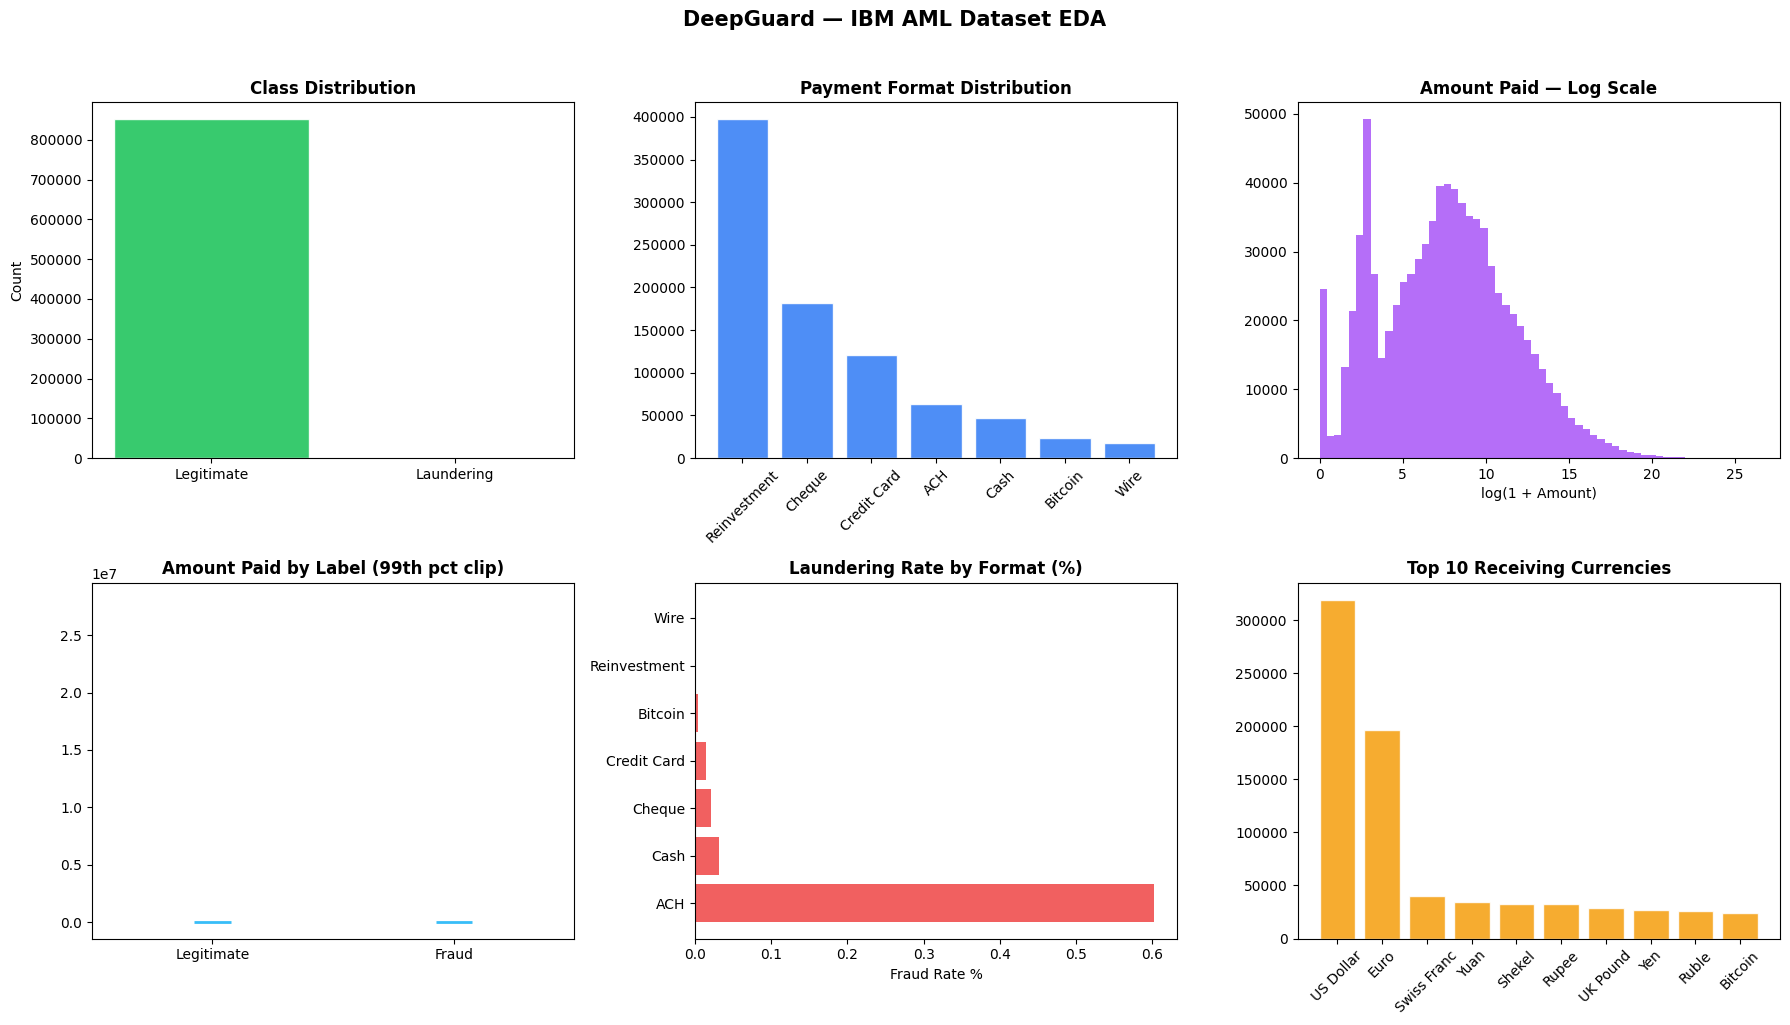

✅ EDA plots saved → /content/eda_plots.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DeepGuard — IBM AML Dataset EDA', fontsize=15, fontweight='bold', y=1.02)
plt.style.use('dark_background')

# 1. Class Distribution
counts = df['Is Laundering'].value_counts()
bars = axes[0,0].bar(['Legitimate', 'Laundering'], counts.values,
                      color=['#22c55e', '#ef4444'], edgecolor='white', alpha=0.9)
axes[0,0].set_title('Class Distribution', fontweight='bold')
axes[0,0].set_ylabel('Count')
for bar, v in zip(bars, counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, v, f'{v:,}',
                   ha='center', va='bottom', fontweight='bold', color='white')

# 2. Payment Format
fmt = df['Payment Format'].value_counts()
axes[0,1].bar(fmt.index, fmt.values, color='#3b82f6', alpha=0.9, edgecolor='white')
axes[0,1].set_title('Payment Format Distribution', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Amount Paid (log)
axes[0,2].hist(np.log1p(df['Amount Paid']), bins=60, color='#a855f7', alpha=0.85, edgecolor='none')
axes[0,2].set_title('Amount Paid — Log Scale', fontweight='bold')
axes[0,2].set_xlabel('log(1 + Amount)')

# 4. Amount by Label
legit_amounts = df[df['Is Laundering']==0]['Amount Paid'].clip(upper=df['Amount Paid'].quantile(0.99))
fraud_amounts = df[df['Is Laundering']==1]['Amount Paid'].clip(upper=df['Amount Paid'].quantile(0.99))
axes[1,0].boxplot([legit_amounts, fraud_amounts], labels=['Legitimate', 'Fraud'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#1e293b'),
                   medianprops=dict(color='#38bdf8', linewidth=2))
axes[1,0].set_title('Amount Paid by Label (99th pct clip)', fontweight='bold')

# 5. Laundering rate by payment format
rate = df.groupby('Payment Format')['Is Laundering'].mean().sort_values(ascending=False) * 100
axes[1,1].barh(rate.index, rate.values, color='#ef4444', alpha=0.85)
axes[1,1].set_title('Laundering Rate by Format (%)', fontweight='bold')
axes[1,1].set_xlabel('Fraud Rate %')

# 6. Top Receiving Currencies
recv = df['Receiving Currency'].value_counts().head(10)
axes[1,2].bar(recv.index, recv.values, color='#f59e0b', alpha=0.85, edgecolor='white')
axes[1,2].set_title('Top 10 Receiving Currencies', fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/eda_plots.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ EDA plots saved → /content/eda_plots.png")

## ⚙️ Step 4 — Feature Engineering & Preprocessing

In [9]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import joblib, os

def preprocess_ibm_aml(df, save_path='/content/preprocessed'):
    os.makedirs(save_path, exist_ok=True)
    df = df.copy()

    # ============================================================
    # 2. DROP MISSING VALUES from fir
    # ============================================================
    before = len(df)
    df = df.dropna()
    after = len(df)
    print(f'✅ Dropped {before - after:,} rows with missing values')

    # ── Timestamp Features ──
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df['Hour']       = df['Timestamp'].dt.hour
    df['DayOfWeek']  = df['Timestamp'].dt.dayofweek
    df['Month']      = df['Timestamp'].dt.month
    df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)
    df['IsNightTx']  = ((df['Hour'] >= 22) | (df['Hour'] <= 5)).astype(int)
    print("  ✅ Timestamp → Hour, DayOfWeek, Month, IsWeekend, IsNightTx")

    # ── Amount Features ──
    df['Amount Paid']     = pd.to_numeric(df['Amount Paid'],     errors='coerce').fillna(0)
    df['Amount Received'] = pd.to_numeric(df['Amount Received'], errors='coerce').fillna(0)
    df['Amount_Ratio']    = df['Amount Paid'] / (df['Amount Received'] + 1e-9)
    df['Amount_Diff']     = df['Amount Paid'] - df['Amount Received']
    df['Log_Amount_Paid'] = np.log1p(df['Amount Paid'])
    df['Log_Amount_Recv'] = np.log1p(df['Amount Received'])
    df['Is_Round_Amount'] = ((df['Amount Paid'] % 1000) == 0).astype(int)
    print("  ✅ Amount features engineered")

    # ── Encode Categoricals ──
    le = LabelEncoder()
    for col in ['Payment Format', 'Payment Currency', 'Receiving Currency']:
        if col in df.columns:
            df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    print("  ✅ Categorical encoding done")

    # ── Account-Level Aggregation ──
    df['Sender_TX_Count']        = df.groupby('Account')['Amount Paid'].transform('count')
    df['Sender_Avg_Amount']      = df.groupby('Account')['Amount Paid'].transform('mean')
    df['Sender_Unique_Receivers']= df.groupby('Account')['Account.1'].transform('nunique')
    df['Sender_Total_Amount']    = df.groupby('Account')['Amount Paid'].transform('sum')
    df['Sender_Max_Amount']      = df.groupby('Account')['Amount Paid'].transform('max')
    df['Receiver_TX_Count']      = df.groupby('Account.1')['Amount Received'].transform('count')
    print("  ✅ Account-level aggregation features done")

    # ── Select Final Features ──
    feature_cols = [
        'Amount Paid', 'Amount Received', 'Amount_Ratio', 'Amount_Diff',
        'Log_Amount_Paid', 'Log_Amount_Recv', 'Is_Round_Amount',
        'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'IsNightTx',
        'Payment Format_enc', 'Payment Currency_enc', 'Receiving Currency_enc',
        'Sender_TX_Count', 'Sender_Avg_Amount', 'Sender_Unique_Receivers',
        'Sender_Total_Amount', 'Sender_Max_Amount', 'Receiver_TX_Count'
    ]
    feature_cols = [c for c in feature_cols if c in df.columns]
    print(f"  ✅ {len(feature_cols)} features selected: {feature_cols}")

    X = df[feature_cols].fillna(0).values
    y = df['Is Laundering'].values

    # ── Split ──
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"  ✅ Split → Train: {X_train.shape} | Test: {X_test.shape}")

    # ── Scale (fit ONLY on normal transactions) ──
    X_train_normal = X_train[y_train == 0]
    scaler = MinMaxScaler()
    scaler.fit(X_train_normal)
    X_train_s = scaler.transform(X_train)
    X_test_s  = scaler.transform(X_test)
    print(f"  ✅ MinMaxScaler fitted on {len(X_train_normal):,} normal transactions")

    # ── Save ──
    np.save(f'{save_path}/X_train.npy', X_train_s)
    np.save(f'{save_path}/X_test.npy',  X_test_s)
    np.save(f'{save_path}/y_train.npy', y_train)
    np.save(f'{save_path}/y_test.npy',  y_test)
    joblib.dump(scaler,       f'{save_path}/scaler.pkl')
    joblib.dump(feature_cols, f'{save_path}/feature_cols.pkl')

    print(f"\n✅ All preprocessing artifacts saved → {save_path}/")
    print("\n📊 Train label distribution:")
    for label, count in zip(*np.unique(y_train, return_counts=True)):
        print(f"   {'Laundering' if label else 'Legitimate':12s}: {count:>8,}  ({count/len(y_train)*100:.3f}%)")

    return X_train_s, X_test_s, y_train, y_test, scaler, feature_cols

print("🔧 Starting preprocessing...")
X_train, X_test, y_train, y_test, scaler, feature_cols = preprocess_ibm_aml(df)
print("\n🎉 Preprocessing complete! Run Notebook 2 next.")

🔧 Starting preprocessing...
✅ Dropped 1 rows with missing values
  ✅ Timestamp → Hour, DayOfWeek, Month, IsWeekend, IsNightTx
  ✅ Amount features engineered
  ✅ Categorical encoding done
  ✅ Account-level aggregation features done
  ✅ 21 features selected: ['Amount Paid', 'Amount Received', 'Amount_Ratio', 'Amount_Diff', 'Log_Amount_Paid', 'Log_Amount_Recv', 'Is_Round_Amount', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'IsNightTx', 'Payment Format_enc', 'Payment Currency_enc', 'Receiving Currency_enc', 'Sender_TX_Count', 'Sender_Avg_Amount', 'Sender_Unique_Receivers', 'Sender_Total_Amount', 'Sender_Max_Amount', 'Receiver_TX_Count']
  ✅ Split → Train: (681550, 21) | Test: (170388, 21)
  ✅ MinMaxScaler fitted on 681,189 normal transactions

✅ All preprocessing artifacts saved → /content/preprocessed/

📊 Train label distribution:
   Legitimate  :  681,189  (99.947%)
   Laundering  :      361  (0.053%)

🎉 Preprocessing complete! Run Notebook 2 next.


In [10]:
# ── Verify saved files ──
import os
SAVE_PATH = '/content/preprocessed'
for f in os.listdir(SAVE_PATH):
    size_mb = os.path.getsize(f'{SAVE_PATH}/{f}') / 1024 / 1024
    print(f"  {f:<30s}  {size_mb:.2f} MB")

print("\n✅ All files verified. Download /content/preprocessed/ if needed.")
print("📌 Proceed to Notebook 2 → 02_Model_Training_and_Evaluation.ipynb")

  y_train.npy                     5.20 MB
  scaler.pkl                      0.00 MB
  feature_cols.pkl                0.00 MB
  y_test.npy                      1.30 MB
  X_train.npy                     109.20 MB
  X_test.npy                      27.30 MB

✅ All files verified. Download /content/preprocessed/ if needed.
📌 Proceed to Notebook 2 → 02_Model_Training_and_Evaluation.ipynb


In [11]:
# 1. Zip the folder
!zip -r /content/preprocessed.zip /content/preprocessed

# 2. Download the zip file to your local computer
from google.colab import files
files.download('/content/preprocessed.zip')


  adding: content/preprocessed/ (stored 0%)
  adding: content/preprocessed/y_train.npy (deflated 100%)
  adding: content/preprocessed/scaler.pkl (deflated 49%)
  adding: content/preprocessed/feature_cols.pkl (deflated 40%)
  adding: content/preprocessed/y_test.npy (deflated 100%)
  adding: content/preprocessed/X_train.npy (deflated 68%)
  adding: content/preprocessed/X_test.npy (deflated 68%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>